# Data Visualization Portfolio project : Bakery Sales Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset
df = pd.read_excel(r"D:\MS_Data_Science_Arden_university\Data Visualisation\Data_Visulisation_Portfolio\PORTFOLIO_DATA_VISUALISATION_Final\Data Visualisation - COM7021 - [4566] Bakery- supporting document.xlsx")
df.head()

,Date,City,Confectionary,Units Sold,Revenue(£),Cost(£),Profit(£)
0,2002-11-11,London,Biscuit,1118.0,5590.0,2459.6,3130.4
1,2002-07-05,London,Biscuit,708.0,3540.0,1557.6,1982.4
2,2001-10-31,London,Biscuit,1269.0,6345.0,2791.8,3553.2
3,2004-09-13,London,Biscuit,1631.0,8155.0,3588.2,4566.8
4,2004-03-10,London,Biscuit,2240.0,11200.0,4928.0,6272.0


In [4]:
print(f"Total Rows   : {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Column Names : {list(df.columns)}")

Total Rows   : 1001
Total Columns: 7
Column Names : ['Date', 'City', 'Confectionary', 'Units Sold', 'Revenue(£)', 'Cost(£)', 'Profit(£)']


In [27]:
#Initial Statistical Overview
numerical_cols_df = df.select_dtypes(include=['number'])
datetime_cols_df  = df.select_dtypes(include=['datetime64'])

print(numerical_cols_df.describe())

for col in datetime_cols_df.columns:
    earliest   = df[col].min().strftime('%d %B %Y')
    latest     = df[col].max().strftime('%d %B %Y')
    date_range = (df[col].max() - df[col].min()).days
    print(f"Earliest: {earliest} | Latest: {latest}"
          f" | Range: {date_range} days")

df.info()

        Units Sold    Revenue(£)       Cost(£)     Profit(£)         Year  \
count  1001.000000   1001.000000   1001.000000   1001.000000  1001.000000   
mean   1632.846653   6828.826174   2812.663137   4016.163037  2002.388611   
std     874.192516   4689.387940   2069.300036   2649.421909     1.690512   
min     200.000000    200.000000     40.000000    160.000000  2000.000000   
25%     941.000000   2972.000000   1204.000000   1873.600000  2001.000000   
50%    1530.500000   5916.000000   2454.000000   3459.000000  2002.000000   
75%    2296.000000   9495.000000   3968.000000   5445.000000  2004.000000   
max    4493.000000  23988.000000  10994.500000  13479.000000  2005.000000   

             Month      Quarter  
count  1001.000000  1001.000000  
mean      6.482517     2.495504  
std       3.494559     1.136763  
min       1.000000     1.000000  
25%       3.000000     1.000000  
50%       6.000000     2.000000  
75%      10.000000     4.000000  
max      12.000000     4.000000  


In [6]:
# Check for missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() /
                      len(df) * 100).round(2),
    'Present Count': df.notnull().sum(),
    'Data Type'    : df.dtypes})
print(missing)

               Missing Count  Missing %  Present Count       Data Type
Date                       0        0.0           1001  datetime64[ns]
City                       0        0.0           1001          object
Confectionary              0        0.0           1001          object
Units Sold                 5        0.5            996         float64
Revenue(£)                 9        0.9            992         float64
Cost(£)                    9        0.9            992         float64
Profit(£)                  3        0.3            998         float64


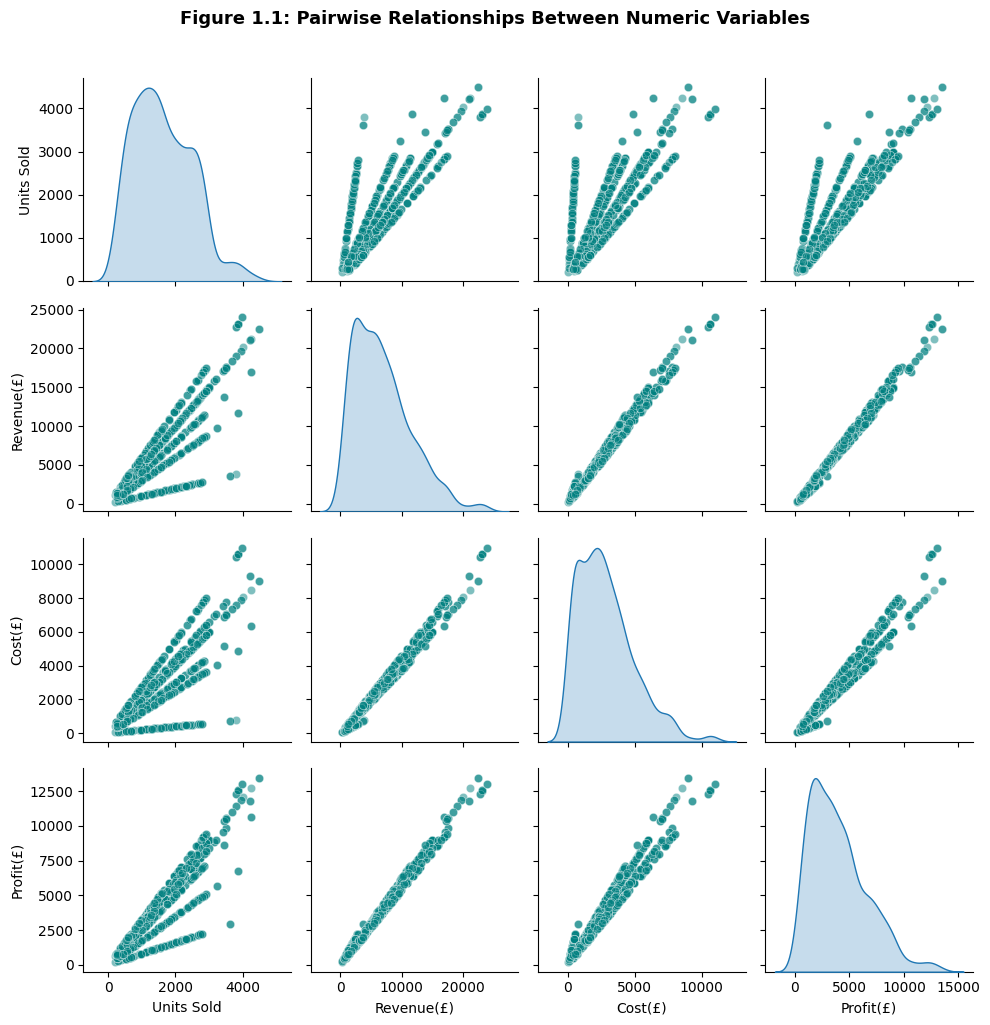

In [7]:
#Statistical Distribution and Variable Relationships
numerical_only = df.select_dtypes(include=['number'])

sns.pairplot(numerical_only,
             diag_kind='kde',
             plot_kws={'alpha': 0.5, 'color': 'teal'})
plt.suptitle(
    'Figure 1.1: Pairwise Relationships'
    ' Between Numeric Variables',
    y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_1_1_Pairplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
#Handling Missing Data
# ============================================================
# SECTION 3.1.8 - HANDLING MISSING DATA
# ============================================================

# ============================================================
# STEP 0: SHOW MISSING VALUES BEFORE TREATMENT
# Always document the state of data BEFORE any changes
# This provides the baseline for pre-post comparison
# (McKinney, 2022, p.239)
# ============================================================

print("=" * 60)
print("PRE-TREATMENT: MISSING VALUES BEFORE")
print("=" * 60)

missing_before = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() /
                      len(df) * 100).round(2),
    'Present Count': df.notnull().sum()
})
print(missing_before)
print(f"\nTotal missing cells BEFORE: "
      f"{df.isnull().sum().sum()}")
print(f"Dataset shape BEFORE      : {df.shape}")

PRE-TREATMENT: MISSING VALUES BEFORE
               Missing Count  Missing %  Present Count
Date                       0        0.0           1001
City                       0        0.0           1001
Confectionary              0        0.0           1001
Units Sold                 5        0.5            996
Revenue(£)                 9        0.9            992
Cost(£)                    9        0.9            992
Profit(£)                  3        0.3            998

Total missing cells BEFORE: 26
Dataset shape BEFORE      : (1001, 7)


In [9]:
# ============================================================
# STEP 1: DROP ROWS WITH MISSING CATEGORICAL IDENTIFIERS
# City, Confectionary and Date cannot be imputed without
# introducing subjective bias that compromises analytical
# integrity (McKinney, 2022, p.241)
# ============================================================

rows_before_drop = len(df)
df.dropna(subset=['City', 'Confectionary', 'Date'],
          inplace=True)
rows_after_drop = len(df)

print(f"\nStep 1 Complete:")
print(f"Rows before categorical drop: {rows_before_drop}")
print(f"Rows after categorical drop : {rows_after_drop}")
print(f"Rows removed                : "
      f"{rows_before_drop - rows_after_drop}")


Step 1 Complete:
Rows before categorical drop: 1001
Rows after categorical drop : 1001
Rows removed                : 0


In [10]:
# ============================================================
# STEP 2: FORMULA-BASED IMPUTATION (2 ROUNDS)
# Uses accounting identity: Revenue = Cost + Profit
# Only resolves rows where at least TWO of the three
# financial variables are present
# Round 2 is necessary because values resolved in Round 1
# unlock additional imputation in dependent columns
# ============================================================

# Round 1
df['Revenue(£)'] = df['Revenue(£)'].fillna(
    df['Cost(£)'] + df['Profit(£)'])
df['Cost(£)'] = df['Cost(£)'].fillna(
    df['Revenue(£)'] - df['Profit(£)'])
df['Profit(£)'] = df['Profit(£)'].fillna(
    df['Revenue(£)'] - df['Cost(£)'])

# Round 2: resolves values unlocked by Round 1
df['Revenue(£)'] = df['Revenue(£)'].fillna(
    df['Cost(£)'] + df['Profit(£)'])
df['Cost(£)'] = df['Cost(£)'].fillna(
    df['Revenue(£)'] - df['Profit(£)'])
df['Profit(£)'] = df['Profit(£)'].fillna(
    df['Revenue(£)'] - df['Cost(£)'])

print("\nStep 2 Complete: Formula imputation (2 rounds)")
print("Remaining missing after formula imputation:")
print(df[['Revenue(£)',
          'Cost(£)',
          'Profit(£)']].isnull().sum())


Step 2 Complete: Formula imputation (2 rounds)
Remaining missing after formula imputation:
Revenue(£)    1
Cost(£)       0
Profit(£)     1
dtype: int64


In [11]:
# ============================================================
# STEP 3: CITY-LEVEL MEDIAN FOR REMAINING MISSING VALUES
# Handles rows where ALL THREE financial values are missing
# simultaneously — formula imputation cannot resolve these
# as NaN + NaN = NaN
# City-level median is more contextually representative
# than overall dataset median
# ============================================================

still_missing = (df[['Revenue(£)',
                      'Cost(£)',
                      'Profit(£)']]
                 .isnull().any(axis=1).sum())

print(f"\nStep 3: Rows still requiring treatment: "
      f"{still_missing}")

if still_missing > 0:
    for col in ['Revenue(£)', 'Cost(£)', 'Profit(£)']:
        city_median = df.groupby('City')[col].transform(
            'median')
        df[col] = df[col].fillna(city_median)
        print(f"  {col}: remaining NaN filled with "
              f"city-level median")

    # Recalculate Profit after all fills for consistency
    df['Profit(£)'] = df['Revenue(£)'] - df['Cost(£)']
    print("  Profit(£): recalculated after median fill")


Step 3: Rows still requiring treatment: 1
  Revenue(£): remaining NaN filled with city-level median
  Cost(£): remaining NaN filled with city-level median
  Profit(£): remaining NaN filled with city-level median
  Profit(£): recalculated after median fill


In [12]:
# ============================================================
# STEP 4: UNITS SOLD FILLED WITH COLUMN MEDIAN
# Median is robust to the outliers identified in
# Section 3.1.12 and preserves distributional shape
# (McKinney, 2022, p.241)
# ============================================================

units_missing_count = df['Units Sold'].isnull().sum()
units_median_value  = df['Units Sold'].median()

df['Units Sold'] = df['Units Sold'].fillna(units_median_value)

print(f"\nStep 4 Complete:")
print(f"Units Sold missing values filled: "
      f"{units_missing_count}")
print(f"Median value used              : "
      f"{units_median_value:.1f}")

# ============================================================
# STEP 5: SAFETY NET
# Drop any rows where financial values remain unresolvable
# This handles extreme edge cases only
# ============================================================

rows_before_safety = len(df)
df.dropna(
    subset=['Revenue(£)', 'Cost(£)', 'Profit(£)'],
    inplace=True)
rows_after_safety = len(df)

print(f"\nStep 5 Safety Net:")
print(f"Rows dropped by safety net: "
      f"{rows_before_safety - rows_after_safety}")


Step 4 Complete:
Units Sold missing values filled: 5
Median value used              : 1530.5

Step 5 Safety Net:
Rows dropped by safety net: 0


In [13]:
# ============================================================
# POST-TREATMENT: MISSING VALUES AFTER
# ============================================================

print("\n" + "=" * 60)
print("POST-TREATMENT: MISSING VALUES AFTER")
print("=" * 60)

missing_after = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() /
                      len(df) * 100).round(2),
    'Present Count': df.notnull().sum()
})
print(missing_after)
print(f"\nTotal missing cells AFTER: "
      f"{df.isnull().sum().sum()}")
print(f"Dataset shape AFTER      : {df.shape}")


POST-TREATMENT: MISSING VALUES AFTER
               Missing Count  Missing %  Present Count
Date                       0        0.0           1001
City                       0        0.0           1001
Confectionary              0        0.0           1001
Units Sold                 0        0.0           1001
Revenue(£)                 0        0.0           1001
Cost(£)                    0        0.0           1001
Profit(£)                  0        0.0           1001

Total missing cells AFTER: 0
Dataset shape AFTER      : (1001, 7)


In [14]:
# ============================================================
# PRE vs POST COMPARISON TABLE
# ============================================================

print("\n" + "=" * 60)
print("PRE vs POST TREATMENT COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Before (Missing)': missing_before['Missing Count'],
    'After  (Missing)': missing_after['Missing Count'],
    'Resolved'        : (
        missing_before['Missing Count'] -
        missing_after['Missing Count'])
})
print(comparison)
print(f"\nTotal missing cells resolved: "
      f"{comparison['Resolved'].sum()}")
print(f"Final dataset shape         : {df.shape}")


PRE vs POST TREATMENT COMPARISON
               Before (Missing)  After  (Missing)  Resolved
Date                          0                 0         0
City                          0                 0         0
Confectionary                 0                 0         0
Units Sold                    5                 0         5
Revenue(£)                    9                 0         9
Cost(£)                       9                 0         9
Profit(£)                     3                 0         3

Total missing cells resolved: 26
Final dataset shape         : (1001, 7)


In [15]:
#Profit Recalculation
# ============================================================
# SECTION 3.1.9 - PROFIT RECALCULATION
# ============================================================

# Uniform recalculation ensures internal consistency and
# eliminates any pre-existing data entry errors in the
# original Profit column (Wilke, 2019)
df['Profit(£)'] = df['Revenue(£)'] - df['Cost(£)']

print("Profit recalculated: Revenue - Cost")
print(f"Profit Min : £{df['Profit(£)'].min():,.2f}")
print(f"Profit Max : £{df['Profit(£)'].max():,.2f}")
print(f"Profit Mean: £{df['Profit(£)'].mean():,.2f}")

Profit recalculated: Revenue - Cost
Profit Min : £160.00
Profit Max : £13,479.00
Profit Mean: £4,016.16


In [16]:
# ============================================================
# SECTION 3.1.10 - TEMPORAL DATA EXTRACTION
#                  AND CATEGORICAL SORTING
# ============================================================

# Date already converted to datetime in Section 3.1.4
# Now extract temporal components as independent columns
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Quarter']    = df['Date'].dt.quarter

# Apply categorical ordering to Month_Name
# Without this, months sort alphabetically not chronologically
# This would render all time-series charts meaningless
# (McKinney, 2022, p.292)
month_order = [
    'January',   'February', 'March',
    'April',     'May',      'June',
    'July',      'August',   'September',
    'October',   'November', 'December'
]

df['Month_Name'] = pd.Categorical(
    df['Month_Name'],
    categories=month_order,
    ordered=True)

print("Temporal extraction complete")
print(f"Years covered : {sorted(df['Year'].unique())}")
print(f"Months found  : {df['Month'].nunique()} months")
print(f"Quarters found: {sorted(df['Quarter'].unique())}")

Temporal extraction complete
Years covered : [np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005)]
Months found  : 12 months
Quarters found: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


In [17]:
# ============================================================
# SECTION 3.1.11 - HANDLING SPELLING ERRORS
# ============================================================

# BEFORE standardisation — show current unique values
print("=" * 60)
print("BEFORE STANDARDISATION")
print("=" * 60)
print("City unique values:")
print(df['City'].unique())
print(f"\nConfectionary unique values:")
print(df['Confectionary'].unique())

# strip() removes leading and trailing whitespace
# title() enforces consistent capitalisation
# Without this, 'london', 'London' and ' London'
# are treated as three separate cities in group-by
# operations, fragmenting all aggregations
# (McKinney, 2022)
df['City'] = df['City'].str.strip().str.title()
df['Confectionary'] = (
    df['Confectionary'].str.strip().str.title())

# AFTER standardisation — confirm resolved values
print("\n" + "=" * 60)
print("AFTER STANDARDISATION")
print("=" * 60)
print("City unique values:")
print(df['City'].unique())
print(f"Total unique cities: {df['City'].nunique()}")
print(f"\nConfectionary unique values:")
print(df['Confectionary'].unique())
print(f"Total unique products: "
      f"{df['Confectionary'].nunique()}")

BEFORE STANDARDISATION
City unique values:
['London' 'Paris' 'Bonn' 'Seville' 'Napoli']

Confectionary unique values:
['Biscuit' 'Biscuit Nut' 'Choclate Chunk' 'Caramel nut' 'Caramel' 'Plain'
 'Chocolate Chunk' 'Caramel Nut']

AFTER STANDARDISATION
City unique values:
['London' 'Paris' 'Bonn' 'Seville' 'Napoli']
Total unique cities: 5

Confectionary unique values:
['Biscuit' 'Biscuit Nut' 'Choclate Chunk' 'Caramel Nut' 'Caramel' 'Plain'
 'Chocolate Chunk']
Total unique products: 7


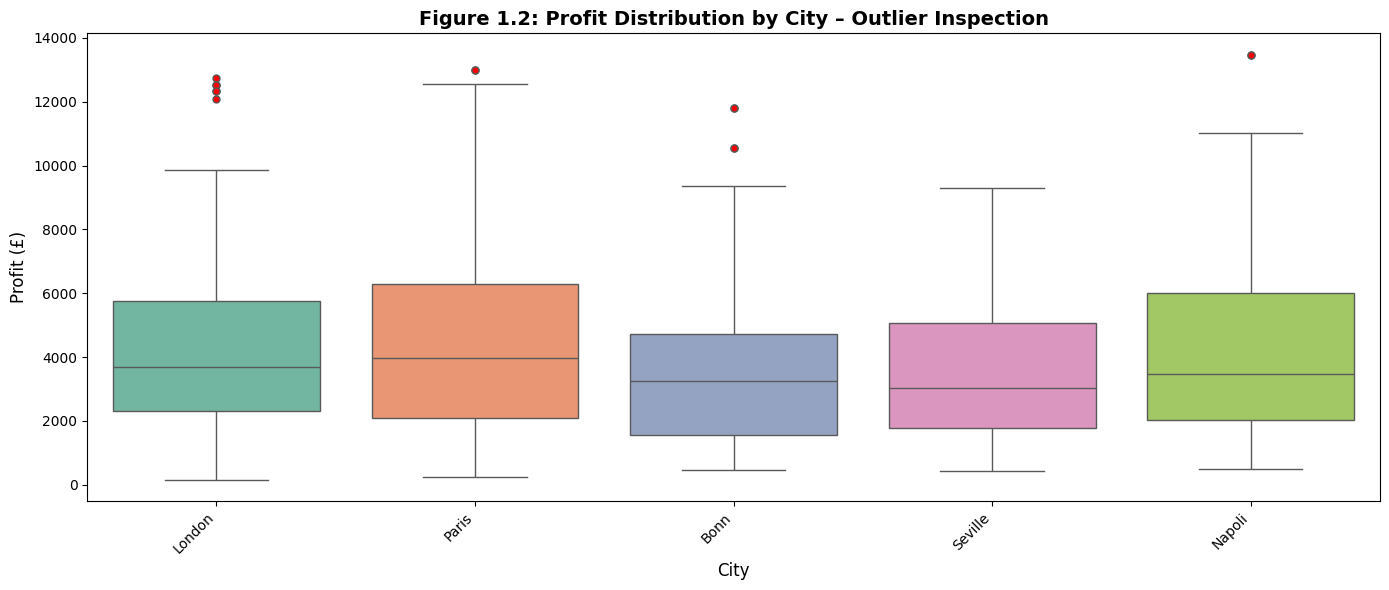


Outlier Summary per City
City: London
  IQR          : £3,440.50
  Lower Bound  : £-2,853.25
  Upper Bound  : £10,908.75
  Outliers     : 6 transactions

City: Paris
  IQR          : £4,228.25
  Lower Bound  : £-4,265.62
  Upper Bound  : £12,647.38
  Outliers     : 2 transactions

City: Bonn
  IQR          : £3,156.00
  Lower Bound  : £-3,180.00
  Upper Bound  : £9,444.00
  Outliers     : 4 transactions

City: Seville
  IQR          : £3,309.05
  Lower Bound  : £-3,192.38
  Upper Bound  : £10,043.83
  Outliers     : 0 transactions

City: Napoli
  IQR          : £3,977.05
  Lower Bound  : £-3,947.82
  Upper Bound  : £11,960.37
  Outliers     : 2 transactions



In [18]:
#Outliers Inspection
# ============================================================
# SECTION 3.1.12 - OUTLIERS INSPECTION
# ============================================================

# Box plot displays median, IQR and outliers beyond 1.5*IQR
# Wilke (2019, p.89): box plots are most effective for
# comparing distributions across multiple groups
# Outliers RETAINED as they represent legitimate
# business transactions that are analytically significant
# Removing valid observations is a consequential error
# in business analytics (Franconeri et al., 2021)

plt.figure(figsize=(14, 6))
sns.boxplot(
    x='City',
    y='Profit(£)',
    data=df,
    palette='Set2',
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markersize=5))
plt.xticks(rotation=45, ha='right')
plt.title(
    'Figure 1.2: Profit Distribution by City'
    ' – Outlier Inspection',
    fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Profit (£)', fontsize=12)
plt.tight_layout()
plt.savefig('Figure_1_2_Boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print numerical outlier summary per city
print("\nOutlier Summary per City")
print("=" * 60)
for city in df['City'].unique():
    city_data = df[df['City'] == city]['Profit(£)']
    Q1  = city_data.quantile(0.25)
    Q3  = city_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = city_data[
        (city_data < lower_bound) |
        (city_data > upper_bound)]
    print(f"City: {city}")
    print(f"  IQR          : £{IQR:,.2f}")
    print(f"  Lower Bound  : £{lower_bound:,.2f}")
    print(f"  Upper Bound  : £{upper_bound:,.2f}")
    print(f"  Outliers     : {len(outliers)} transactions")
    print()

In [19]:
# ============================================================
# SECTION 4.1.2 - PROFIT BY CITY AND PRODUCT (Figure 2.2)
# ============================================================

city_product_profit = (
    df.groupby(['City', 'Confectionary'])['Profit(£)']
    .sum()
    .reset_index())

fig22 = px.bar(
    city_product_profit,
    x='City',
    y='Profit(£)',
    color='Confectionary',
    title='Figure 2.2: Profit Contribution'
          ' by City and Product',
    barmode='stack',
    labels={'Profit(£)': 'Total Profit (£)'},
    color_discrete_sequence=
    px.colors.qualitative.Set2)
fig22.update_layout(
    xaxis_tickangle=-45,
    legend_title='Confectionary Type',
    height=550,
    title_font_size=14)
fig22.write_html('Figure_2_2_CityProductProfit.html')
fig22.show()

In [20]:
# ============================================================
# SECTION 4.1.3 - PROFIT TREND BY CITY (Figure 2.3)
# ============================================================

yearly_profit = (
    df.groupby(['Year', 'City'])['Profit(£)']
    .sum()
    .reset_index())

fig23 = px.line(
    yearly_profit,
    x='Year',
    y='Profit(£)',
    color='City',
    title='Figure 2.3: Annual Profit Trend by City',
    markers=True,
    labels={
        'Profit(£)': 'Total Profit (£)',
        'Year': 'Financial Year'},
    color_discrete_sequence=
    px.colors.qualitative.Plotly)
fig23.update_traces(line=dict(width=2))
fig23.update_layout(
    height=500,
    legend_title='City',
    title_font_size=14)
fig23.write_html('Figure_2_3_YearlyTrend.html')
fig23.show()

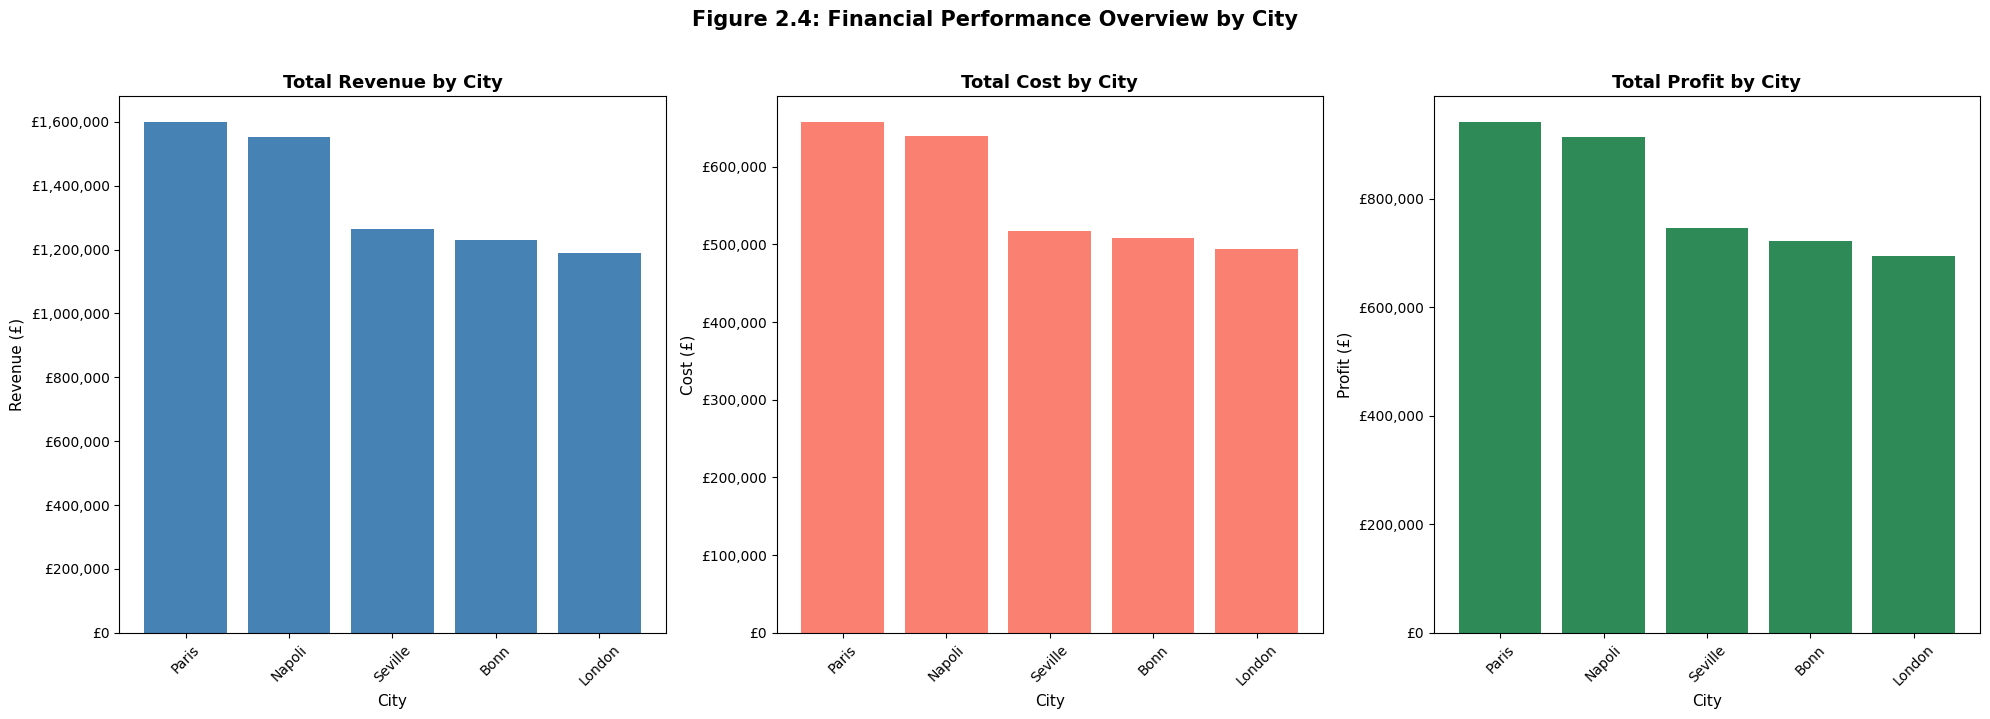

In [21]:
# ============================================================
# SECTION 4.2 - FINANCIAL PERFORMANCE ANALYSIS (Figure 2.4)
# ============================================================

fig24, axes = plt.subplots(1, 3, figsize=(20, 7))
metrics = [
    ('Revenue(£)', 'steelblue', 'Revenue'),
    ('Cost(£)',    'salmon',    'Cost'),
    ('Profit(£)', 'seagreen',  'Profit')
]
for ax, (col, colour, label) in zip(axes, metrics):
    data = (
        df.groupby('City')[col]
        .sum()
        .sort_values(ascending=False))
    ax.bar(data.index, data.values, color=colour)
    ax.set_title(
        f'Total {label} by City',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('City', fontsize=11)
    ax.set_ylabel(f'{label} (£)', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f'£{x:,.0f}'))
plt.suptitle(
    'Figure 2.4: Financial Performance Overview by City',
    fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure_2_4_FinancialOverview.png',
            dpi=150, bbox_inches='tight')
plt.show()

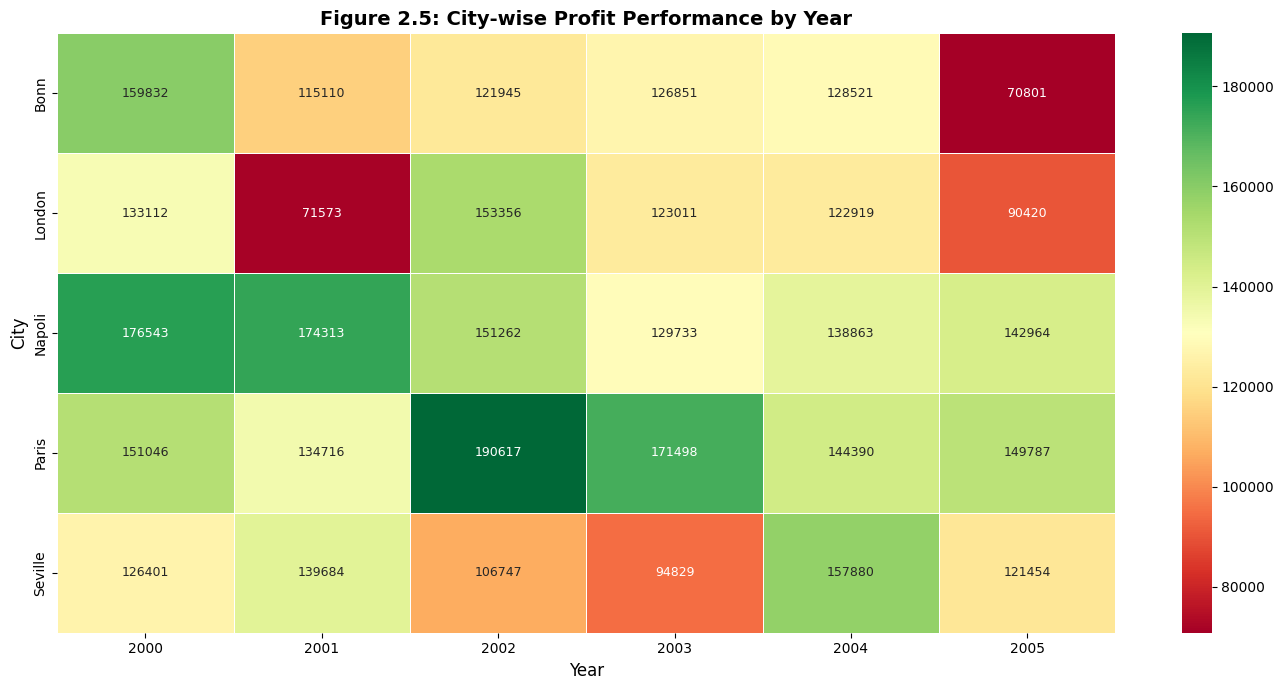

In [36]:
# ============================================================
# SECTION 4.3.1 - CITY-YEAR HEATMAP (Figure 2.5)
# ============================================================

pivot_city_year = df.pivot_table(
    values='Profit(£)',
    index='City',
    columns='Year',
    aggfunc='sum')

plt.figure(figsize=(14, 7))
sns.heatmap(
    pivot_city_year,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9})
plt.title(
    'Figure 2.5: City-wise Profit Performance by Year',
    fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
plt.savefig('Figure_2_5_CityYearHeatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

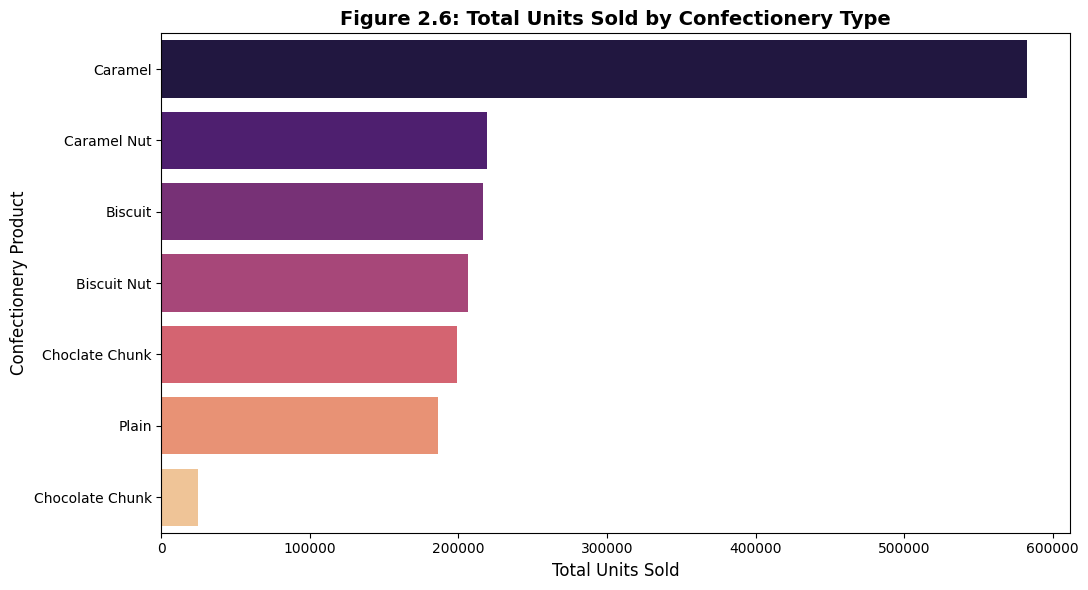

In [23]:
# ============================================================
# SECTION 4.4.1 - UNITS SOLD BY PRODUCT (Figure 2.6)
# ============================================================

product_units = (
    df.groupby('Confectionary')['Units Sold']
    .sum()
    .sort_values(ascending=False)
    .reset_index())

plt.figure(figsize=(11, 6))
sns.barplot(
    data=product_units,
    x='Units Sold',
    y='Confectionary',
    palette='magma',
    orient='h')
plt.title(
    'Figure 2.6: Total Units Sold'
    ' by Confectionery Type',
    fontsize=14, fontweight='bold')
plt.xlabel('Total Units Sold', fontsize=12)
plt.ylabel('Confectionery Product', fontsize=12)
plt.tight_layout()
plt.savefig('Figure_2_6_UnitsSold.png',
            dpi=150, bbox_inches='tight')
plt.show()

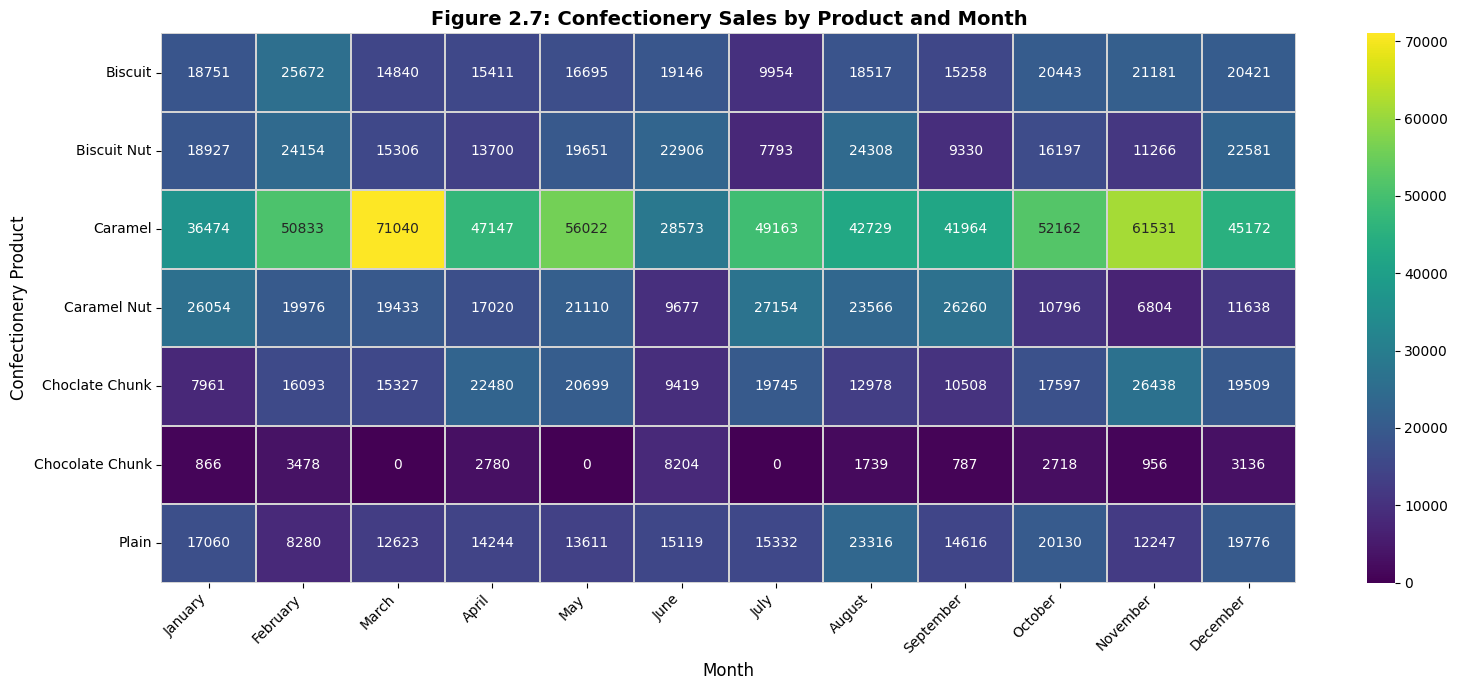

In [37]:
# ============================================================
# SECTION 4.4.2 - MONTHLY SALES HEATMAP (Figure 2.7)
# ============================================================

monthly_product = df.pivot_table(
    values='Units Sold',
    index='Confectionary',
    columns='Month_Name',
    aggfunc='sum')
monthly_product = monthly_product[month_order]

plt.figure(figsize=(16, 7))
sns.heatmap(
    monthly_product,
    annot=True,
    fmt='.0f',
    cmap='viridis',
    linewidths=0.3,
    linecolor='lightgrey')
plt.title(
    'Figure 2.7: Confectionery Sales'
    ' by Product and Month',
    fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Confectionery Product', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Figure_2_7_MonthlyHeatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

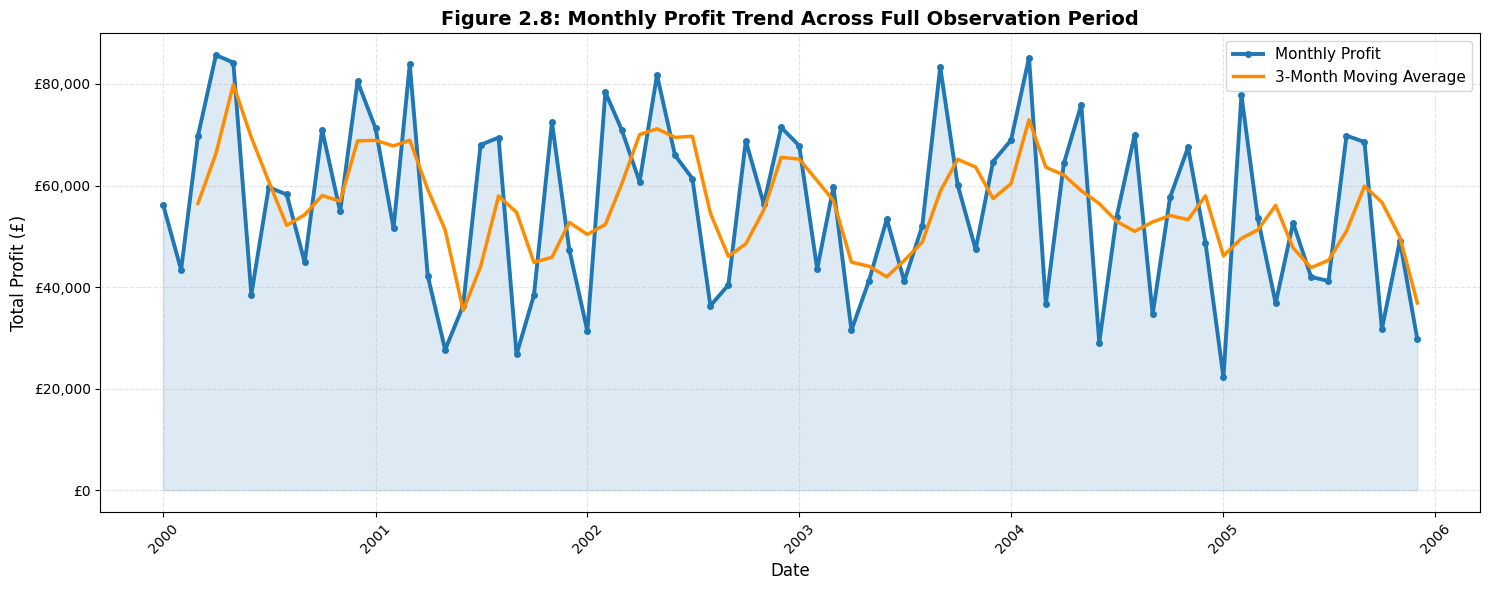

In [38]:
# ============================================================
# SECTION 4.5 - TIME-BASED TREND ANALYSIS (Figure 2.8)
# ============================================================

plt.figure(figsize=(15, 6))

# Main line
plt.plot(
    monthly_profit['Date'],
    monthly_profit['Profit(£)'],
    color='#1f77b4', linewidth=2.8,
    marker='o', markersize=4,
    label='Monthly Profit'
)

# Fill
plt.fill_between(
    monthly_profit['Date'],
    monthly_profit['Profit(£)'],
    alpha=0.15, color='#1f77b4'
)

# Moving average
monthly_profit['MA3'] = monthly_profit['Profit(£)'].rolling(3).mean()
plt.plot(
    monthly_profit['Date'],
    monthly_profit['MA3'],
    color='darkorange', linewidth=2.5,
    label='3-Month Moving Average'
)

# Formatting
plt.title(
    'Figure 2.8: Monthly Profit Trend Across Full Observation Period',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Profit (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.35)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('Figure_2_8_MonthlyTrend.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# ============================================================
# SECTION 5 - INTERACTIVE DASHBOARD (Figure 3.1)
# ============================================================
# Five-panel dashboard incorporating bar charts, pie charts
# and line charts to provide a comprehensive multi-perspective
# view of European bakery performance
# Following Few (2022, p.34): information density with clarity
# Pie charts added for part-to-whole profit share analysis
# (Wilke, 2019, p.111)

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Define colour palette for consistent city colours
# across all panels (Healy, 2018)
city_colours = [
    '#2ecc71',  # green
    '#3498db',  # blue
    '#e74c3c',  # red
    '#f39c12',  # orange
    '#9b59b6',  # purple
    '#1abc9c',  # teal
    '#e67e22',  # dark orange
]

product_colours = [
    '#FF6B6B',  # coral red
    '#4ECDC4',  # teal
    '#45B7D1',  # sky blue
    '#96CEB4',  # sage green
    '#FFEAA7',  # pale yellow
    '#DDA0DD',  # plum
    '#98D8C8',  # mint
]

# ============================================================
# PREPARE DATA FOR ALL PANELS
# ============================================================

# City profit data
city_p = (
    df.groupby('City')['Profit(£)']
    .sum()
    .sort_values(ascending=False)
    .reset_index())

# Product profit data
prod_p = (
    df.groupby('Confectionary')['Profit(£)']
    .sum()
    .sort_values(ascending=False)
    .reset_index())

# Yearly city profit data
yearly_city = (
    df.groupby(['City', 'Year'])['Profit(£)']
    .sum()
    .reset_index())

# Revenue vs Cost by City
rev_cost = df.groupby('City').agg(
    Revenue=('Revenue(£)', 'sum'),
    Cost=('Cost(£)', 'sum'),
    Profit=('Profit(£)', 'sum')
).reset_index()

# ============================================================
# CREATE FIVE-PANEL DASHBOARD LAYOUT
# ============================================================

fig31 = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        'Total Profit by City',
        'Profit Share by City (%)',
        'Annual Profit Trend by City',
        'Product Profit Share (%)',
        'Revenue vs Cost vs Profit by City',
        ''),
    specs=[
        [{'type': 'bar'},     {'type': 'pie'}],
        [{'type': 'scatter'}, {'type': 'pie'}],
        [{'type': 'bar',
          'colspan': 2},      None]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.10)

# ============================================================
# PANEL 1 (Row 1, Col 1): Total Profit by City - Bar Chart
# Sorted descending for immediate performance hierarchy
# (Knaflic, 2015, p.61)
# ============================================================
fig31.add_trace(
    go.Bar(
        x=city_p['City'],
        y=city_p['Profit(£)'],
        name='City Profit',
        marker=dict(
            color=city_colours[:len(city_p)],
            line=dict(color='white', width=1.5)),
        text=[f'£{v:,.0f}'
              for v in city_p['Profit(£)']],
        textposition='outside',
        hovertemplate=(
            '<b>%{x}</b><br>'
            'Total Profit: £%{y:,.0f}<br>'
            '<extra></extra>')),
    row=1, col=1)

# ============================================================
# PANEL 2 (Row 1, Col 2): Profit Share by City - Pie Chart
# Donut pie chart for part-to-whole city profit share
# Each city percentage contribution to total profit
# (Wilke, 2019, p.111)
# ============================================================
fig31.add_trace(
    go.Pie(
        labels=city_p['City'],
        values=city_p['Profit(£)'],
        name='City Profit Share',
        marker=dict(
            colors=city_colours[:len(city_p)],
            line=dict(color='white', width=2)),
        textinfo='label+percent',
        textposition='outside',
        hovertemplate=(
            '<b>%{label}</b><br>'
            'Profit: £%{value:,.0f}<br>'
            'Share: %{percent}<br>'
            '<extra></extra>'),
        hole=0.3),
    row=1, col=2)

# ============================================================
# PANEL 3 (Row 2, Col 1): Annual Profit by City - Line Chart
# Multi-line chart for temporal trajectory comparison
# Each city assigned consistent colour (Healy, 2018)
# Enables identification of structurally declining vs
# cyclically recovering locations (Ware, 2020, p.176)
# ============================================================
for i, city in enumerate(yearly_city['City'].unique()):
    city_data = yearly_city[
        yearly_city['City'] == city]
    fig31.add_trace(
        go.Scatter(
            x=city_data['Year'],
            y=city_data['Profit(£)'],
            mode='lines+markers',
            name=city,
            line=dict(
                color=city_colours[
                    i % len(city_colours)],
                width=2.5),
            marker=dict(size=7),
            hovertemplate=(
                f'<b>{city}</b><br>'
                'Year: %{x}<br>'
                'Profit: £%{y:,.0f}<br>'
                '<extra></extra>')),
        row=2, col=1)

# ============================================================
# PANEL 4 (Row 2, Col 2): Product Profit Share - Pie Chart
# Donut pie chart for product-level profit composition
# Reveals which products drive the most profit
# (Wilke, 2019, p.111)
# ============================================================
fig31.add_trace(
    go.Pie(
        labels=prod_p['Confectionary'],
        values=prod_p['Profit(£)'],
        name='Product Profit Share',
        marker=dict(
            colors=product_colours[:len(prod_p)],
            line=dict(color='white', width=2)),
        textinfo='label+percent',
        textposition='outside',
        hovertemplate=(
            '<b>%{label}</b><br>'
            'Profit: £%{value:,.0f}<br>'
            'Share: %{percent}<br>'
            '<extra></extra>'),
        hole=0.35),
    row=2, col=2)

# ============================================================
# PANEL 5 (Row 3, Col 1-2): Revenue vs Cost - Grouped Bar
# Spans full width using colspan=2 for maximum clarity
# Grouped bar chart for direct Revenue vs Cost comparison
# Reveals cities where cost erodes revenue most significantly
# (Healy, 2018, p.22)
# ============================================================
fig31.add_trace(
    go.Bar(
        x=rev_cost['City'],
        y=rev_cost['Revenue'],
        name='Revenue',
        marker=dict(
            color='#3498DB',
            line=dict(color='white', width=1)),
        hovertemplate=(
            '<b>%{x}</b><br>'
            'Revenue: £%{y:,.0f}<br>'
            '<extra></extra>')),
    row=3, col=1)

fig31.add_trace(
    go.Bar(
        x=rev_cost['City'],
        y=rev_cost['Cost'],
        name='Cost',
        marker=dict(
            color='#E74C3C',
            line=dict(color='white', width=1)),
        hovertemplate=(
            '<b>%{x}</b><br>'
            'Cost: £%{y:,.0f}<br>'
            '<extra></extra>')),
    row=3, col=1)

fig31.add_trace(
    go.Bar(
        x=rev_cost['City'],
        y=rev_cost['Profit'],
        name='Profit',
        marker=dict(
            color='#2ECC71',
            line=dict(color='white', width=1)),
        hovertemplate=(
            '<b>%{x}</b><br>'
            'Profit: £%{y:,.0f}<br>'
            '<extra></extra>')),
    row=3, col=1)

# ============================================================
# DASHBOARD LAYOUT AND STYLING
# ============================================================
fig31.update_layout(
    height=1100,
    title=dict(
        text=(
            'Figure 3.1: European Bakery Sales'
            ' – Interactive Performance Dashboard'),
        font=dict(size=18, color='#2C3E50'),
        x=0.5,
        xanchor='center'),
    showlegend=True,
    legend=dict(
        title=dict(text='Category'),
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='lightgrey',
        borderwidth=1),
    paper_bgcolor='#F8F9FA',
    plot_bgcolor='rgba(255,255,255,0.8)',
    barmode='group',
    font=dict(
        family='Arial',
        size=11,
        color='#2C3E50'),
    hoverlabel=dict(
        bgcolor='white',
        font_size=12,
        font_family='Arial'))

# Update axes for bar and scatter panels
fig31.update_xaxes(
    showgrid=True,
    gridcolor='rgba(200,200,200,0.3)',
    tickangle=-45)
fig31.update_yaxes(
    showgrid=True,
    gridcolor='rgba(200,200,200,0.3)',
    tickprefix='£')

# ============================================================
# SAVE AND DISPLAY
# ============================================================
fig31.write_html(
    'Figure_3_1_InteractiveDashboard.html')
fig31.show()

print("\nFigure 3.1 saved as:"
      " Figure_3_1_InteractiveDashboard.html")
print("Open in any web browser to view"
      " full interactive dashboard")


Figure 3.1 saved as: Figure_3_1_InteractiveDashboard.html
Open in any web browser to view full interactive dashboard
